In [33]:
import pandas as pd

In [34]:
subject_teams = [
    "PHI", "CHI", "MIL", 
    "BKN", "CHA", "IND", 
    "CLE", "MIA", "DEN", 
    "ATL", "PHX", "ORL", 
    "NOP", "SAS", "MEM", 
    "WAS", "MIN", "GSW", 
    "HOU", "LAC", "UTA", 
    "SAC", "POR", "LAL"
]

In [35]:
from data_manager import DataManager
dm = DataManager()

In [36]:
exam_players = dm.get_players_in_teams(subject_teams)

In [37]:
exam_players_data = dm.get_player_logs(exam_players)

In [38]:
print(dm.db_team_id_map)

{1610612746: 10, 1610612747: 11, 1610612748: 12, 1610612749: 13, 1610612750: 14, 1610612751: 15, 1610612752: 16, 1610612753: 17, 1610612754: 18, 1610612755: 19, 1610612756: 20, 1610612757: 21, 1610612758: 22, 1610612759: 23, 1610612760: 24, 1610612761: 25, 1610612762: 26, 1610612763: 27, 1610612764: 28, 1610612765: 29, 1610612766: 30, 1610612737: 1, 1610612738: 2, 1610612739: 3, 1610612740: 4, 1610612741: 5, 1610612742: 6, 1610612743: 7, 1610612744: 8, 1610612745: 9}


In [39]:
team_abbreviation_map = dm.nba_team_id_abbreviation_map



In [40]:
print(team_abbreviation_map)

{1610612746: 'LAC', 1610612747: 'LAL', 1610612748: 'MIA', 1610612749: 'MIL', 1610612750: 'MIN', 1610612751: 'BKN', 1610612752: 'NYK', 1610612753: 'ORL', 1610612754: 'IND', 1610612755: 'PHI', 1610612756: 'PHX', 1610612757: 'POR', 1610612758: 'SAC', 1610612759: 'SAS', 1610612760: 'OKC', 1610612761: 'TOR', 1610612762: 'UTA', 1610612763: 'MEM', 1610612764: 'WAS', 1610612765: 'DET', 1610612766: 'CHA', 1610612737: 'ATL', 1610612738: 'BOS', 1610612739: 'CLE', 1610612740: 'NOP', 1610612741: 'CHI', 1610612742: 'DAL', 1610612743: 'DEN', 1610612744: 'GSW', 1610612745: 'HOU'}


In [41]:
print(type(exam_players))
print(len(exam_players))
print(exam_players[0])

<class 'list'>
2110
('James Harden', 1610612746)


In [42]:
players_and_team_abbreviations = {}
for player, nba_team_id in exam_players:
    players_and_team_abbreviations[player] = team_abbreviation_map[nba_team_id]

In [43]:
from collections import defaultdict

team_player_map = defaultdict(list)
for player, team in players_and_team_abbreviations.items():
    team_player_map[team].append(player)

In [44]:
player_data_by_team = {}
for team_abr in subject_teams:
    players_on_team = team_player_map[team_abr]
    team_player_game_logs = []
    for player in players_on_team:
        player_id = dm.get_player_id(player)
        game_data = dm.get_and_save_player_data(player_id)
        team_player_game_logs.append(game_data)
    player_data_by_team[team_abr] = pd.concat(team_player_game_logs)
        

In [45]:

def filter_games_by_date(team_df, start_date):
    """
    Filters the games for a team DataFrame to include only games on or after a specific date.
    
    Parameters:
        team_df (pd.DataFrame): The team's DataFrame with game data.
        start_date (str): The start date in 'YYYY-MM-DD' format.
    
    Returns:
        pd.DataFrame: Filtered DataFrame with games on or after the specified date.
    """
    # Ensure the 'date' column is in datetime format
    team_df['date'] = pd.to_datetime(team_df['date'])
    
    # Filter rows where the game date is on or after the specified start date
    filtered_df = team_df[team_df['date'] >= pd.to_datetime(start_date)]
    
    return filtered_df

In [46]:
df = filter_games_by_date(player_data_by_team['PHI'], "2024-12-01")

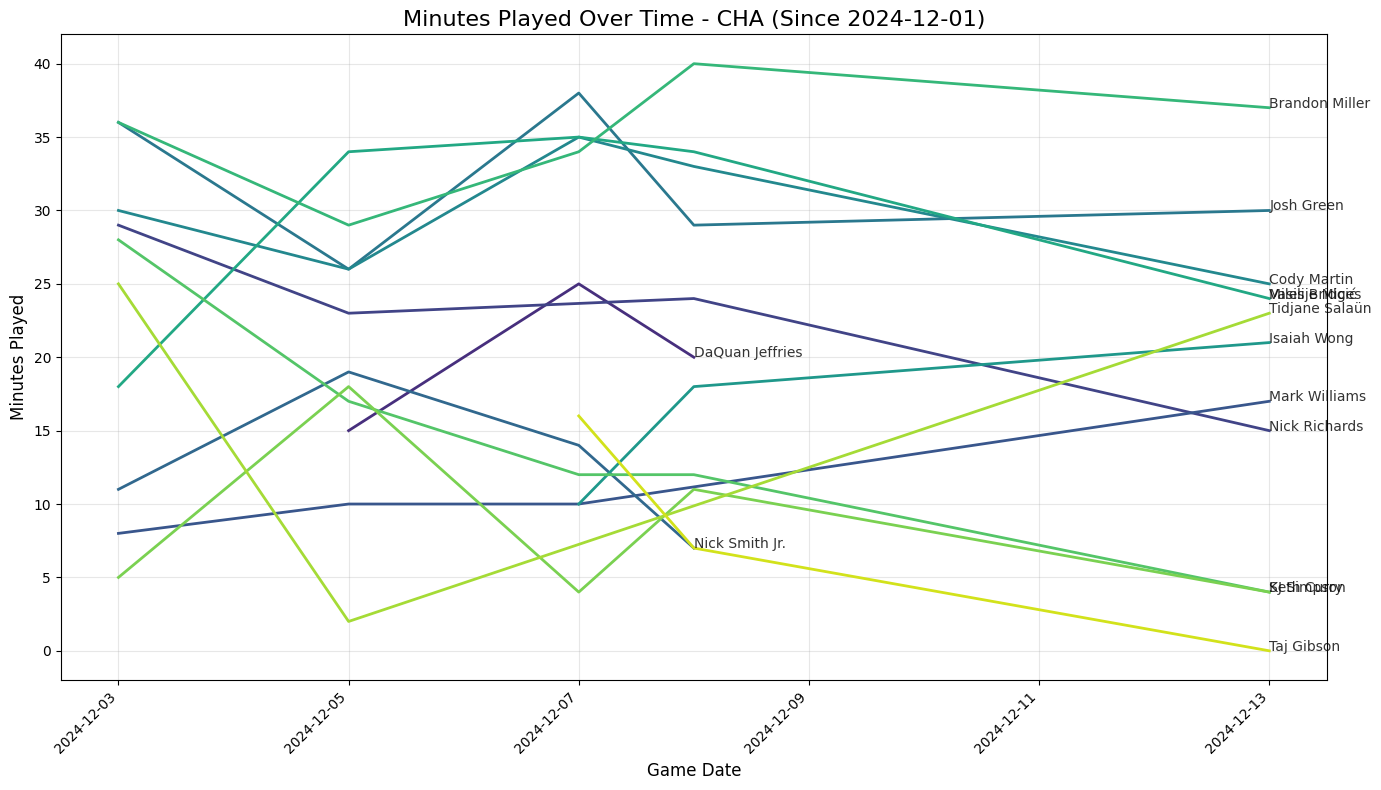

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_minutes_played_with_labels(team_df, team_name, start_date):
    """
    Filters games by a specific date and plots minutes played over time for all players on a team,
    with labels directly on the lines and diagonal x-axis labels.
    
    Parameters:
        team_df (pd.DataFrame): DataFrame containing game data for all players on the team.
        team_name (str): The name of the team (used for the plot title).
        start_date (str): The start date (in 'YYYY-MM-DD' format) to filter games.
    
    Returns:
        None
    """
    # Ensure 'date' is in datetime format
    team_df['date'] = pd.to_datetime(team_df['date'])
    
    # Filter games by start date
    filtered_df = team_df[team_df['date'] >= pd.to_datetime(start_date)]

    # Create the plot
    plt.figure(figsize=(14, 8))
    sns.lineplot(
        data=filtered_df,
        x='date',
        y='minutes',
        hue='player_name',
        palette='viridis',
        linewidth=2,
        legend=None  # Disable the legend since we're adding labels
    )

    # Label each line with the player's name
    for player_name in filtered_df['player_name'].unique():
        # Get the subset of data for the player
        player_data = filtered_df[filtered_df['player_name'] == player_name]
        
        # Find the last (most recent) point for this player
        last_date = player_data['date'].max()
        last_minutes = player_data[player_data['date'] == last_date]['minutes'].values[0]
        
        # Add the label to the plot
        plt.text(
            x=last_date,
            y=last_minutes,
            s=player_name,
            fontsize=10,
            color='black',
            alpha=0.8
        )

    # Style the plot
    plt.title(f'Minutes Played Over Time - {team_name} (Since {start_date})', fontsize=16)
    plt.xlabel('Game Date', fontsize=12)
    plt.ylabel('Minutes Played', fontsize=12)
    plt.grid(alpha=0.3)

    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')  # Rotate labels diagonally for readability

    plt.tight_layout()

    # Show the plot
    plt.show()

# Example usage
team_to_look = "CHA"
df = player_data_by_team[team_to_look]  # Replace with the actual DataFrame
plot_minutes_played_with_labels(df, team_to_look, "2024-12-01")

